# Importing Libraries and Files


In [1]:
!pip install geopandas rasterio rasterstats matplotlib fiona pyproj shapely

In [2]:
from google.colab import files

# Upload both files
uploaded = files.upload()
# Upload mosaic_wgs84_2021_LC_Type1.tif
# Upload KPK_tehsil.zip

Saving KPK_tehsil.zip to KPK_tehsil (1).zip
Saving mosaic_wgs84_2021_LC_Type1.tif to mosaic_wgs84_2021_LC_Type1 (1).tif


In [3]:
import zipfile
import os

with zipfile.ZipFile('KPK_tehsil.zip', 'r') as zip_ref:
    zip_ref.extractall('KPK_tehsil')

# Check extracted contents
for f in os.listdir('KPK_tehsil'):
    print(f)

KPK_tehsil.cpg
KPK_tehsil.sbx
KPK_tehsil.prj
KPK_tehsil.shp
KPK_tehsil.sbn
KPK_tehsil.dbf
KPK_tehsil.shx
KPK_tehsil.shp.xml


# Checking If CRS Matches


In [6]:
import geopandas as gpd
import rasterio
from rasterio.crs import CRS

# Load shapefile (adjust filename if needed)
shapefile_path = 'KPK_tehsil/KPK_tehsil.shp'  # adjust if different
gdf = gpd.read_file(shapefile_path)

# Open raster
raster_path = 'mosaic_wgs84_2021_LC_Type1.tif'

with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    print("Raster CRS:", raster_crs)

print("Shapefile CRS:", gdf.crs)
print("\nCRS Match:", raster_crs == gdf.crs)

Raster CRS: EPSG:4326
Shapefile CRS: EPSG:4326

CRS Match: True


# Reprojection if CRS Doesnt Match

In [7]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    raster_data = src.read(1)
    raster_transform = src.transform
    raster_meta = src.meta.copy()

# Reproject shapefile to match raster CRS if needed
if gdf.crs != raster_crs:
    print("Reprojecting shapefile to match raster CRS...")
    gdf = gdf.to_crs(raster_crs)
    print("Reprojection done.")
else:
    print("CRS already match. No reprojection needed.")

print("Final Shapefile CRS:", gdf.crs)

CRS already match. No reprojection needed.
Final Shapefile CRS: EPSG:4326


# Clipping Raster

In [8]:
import numpy as np
from rasterio.mask import mask
from shapely.geometry import mapping

# Get geometry of all tehsils combined
geometries = [mapping(geom) for geom in gdf.geometry]

with rasterio.open(raster_path) as src:
    clipped_data, clipped_transform = mask(src, geometries, crop=True, nodata=255)
    clipped_meta = src.meta.copy()

clipped_meta.update({
    "driver": "GTiff",
    "height": clipped_data.shape[1],
    "width": clipped_data.shape[2],
    "transform": clipped_transform,
    "nodata": 255
})

# Save clipped raster
clipped_path = 'clipped_modis.tif'
with rasterio.open(clipped_path, 'w', **clipped_meta) as dest:
    dest.write(clipped_data)

print("Clipped raster saved!")
print("Clipped shape:", clipped_data.shape)

Clipped raster saved!
Clipped shape: (1, 1382, 1175)


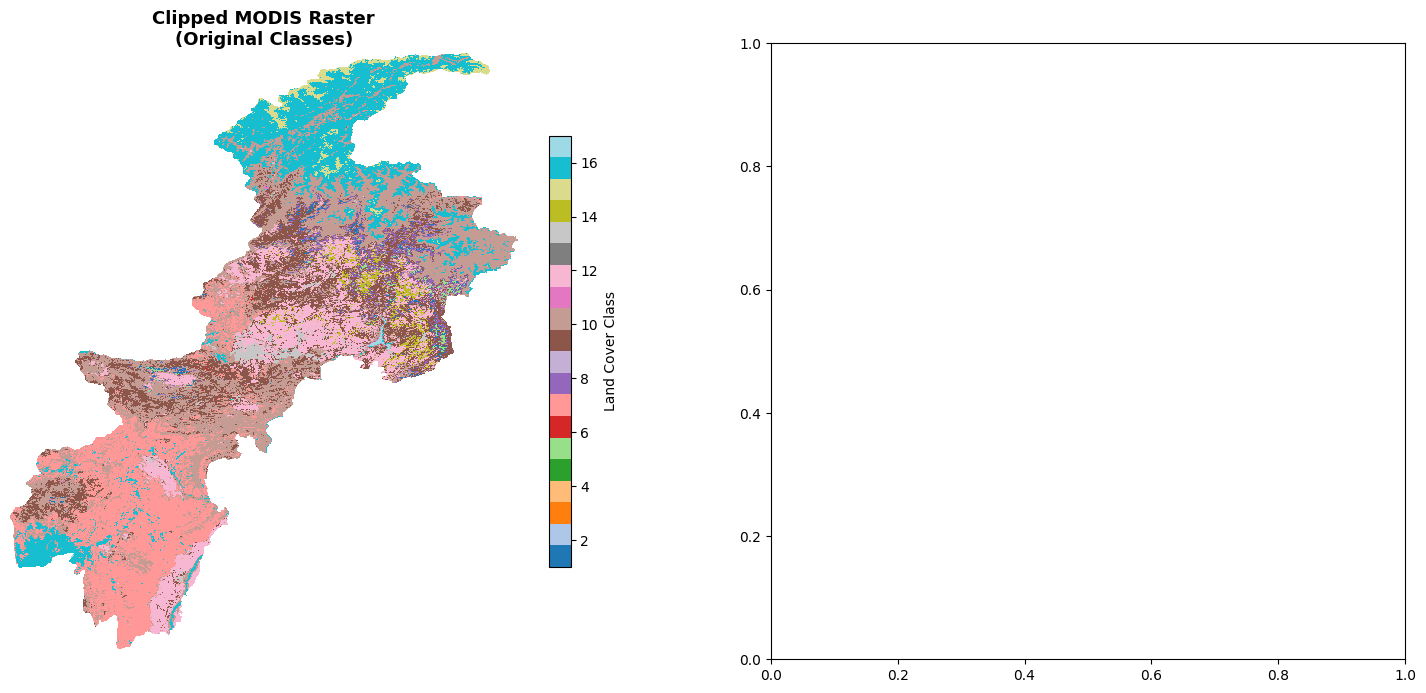

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from rasterio.plot import show

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Plot 1: Clipped Raster ---
with rasterio.open(clipped_path) as src:
    clipped_vis = src.read(1).astype(float)
    clipped_transform = src.transform
    clipped_vis[clipped_vis == 255] = np.nan  # mask nodata

im1 = axes[0].imshow(
    clipped_vis,
    cmap='tab20',
    interpolation='none'
)
axes[0].set_title('Clipped MODIS Raster\n(Original Classes)', fontsize=13, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], shrink=0.7, label='Land Cover Class')

# Reclassifying Raster

In [11]:
# Load clipped raster
with rasterio.open(clipped_path) as src:
    data = src.read(1).astype(np.float32)
    meta = src.meta.copy()
    nodata_val = src.nodata

# Reclassification
reclassified = np.zeros_like(data, dtype=np.uint8)

reclassified[np.isin(data, [1, 2, 3, 4, 5])] = 1   # Forest
reclassified[data == 10] = 2                          # Grasslands
reclassified[data == 14] = 3                          # Croplands
# All others remain 0

# Preserve nodata
if nodata_val is not None:
    reclassified[data == nodata_val] = 255

# Save reclassified raster
reclass_path = 'reclassified_modis.tif'
meta.update({'dtype': 'uint8', 'nodata': 255})

with rasterio.open(reclass_path, 'w', **meta) as dest:
    dest.write(reclassified, 1)

print("Reclassified raster saved!")
print("Unique values:", np.unique(reclassified))

Reclassified raster saved!
Unique values: [  0   1   2   3 255]


,OBJECTID,PROVINCE,DISTRICT,TEHSIL,SHAPE_Leng,Area_Sq_Km,Shape_Le_1,Shape_Area,geometry
0,150,FATA,BAJAUR AGENCY,BAR CHAMARKAND,0.161485,16.632682,0.161485,0.001637,"POLYGON ((71.22452 34.7539, 71.22499 34.75334,..."
1,151,FATA,BAJAUR AGENCY,BARANG,0.843519,266.801410,0.843519,0.026209,"POLYGON ((71.58568 34.72182, 71.58604 34.72165..."
2,152,FATA,BAJAUR AGENCY,KHAR,1.122599,276.057546,1.122599,0.027156,"POLYGON ((71.62753 34.80824, 71.62794 34.80821..."
3,153,FATA,BAJAUR AGENCY,MAMUND,0.760798,265.629641,0.760798,0.026165,"POLYGON ((71.48933 34.8027, 71.48888 34.80227,..."
4,154,FATA,BAJAUR AGENCY,NAWAGAI,0.529303,126.869064,0.529303,0.012484,"POLYGON ((71.30391 34.78343, 71.30448 34.78334..."
...,...,...,...,...,...,...,...,...,...
117,81,KHYBER PAKHTUNKHWA,Peshawar,Peshawar I,1.522667,24.410146,0.312646,0.002381,"POLYGON ((71.59496 34.04249, 71.59506 34.03959..."
118,81,KHYBER PAKHTUNKHWA,Peshawar,Peshawar II,1.522667,413.813252,1.395795,0.040405,"POLYGON ((71.48087 34.20435, 71.48428 34.20153..."
119,81,KHYBER PAKHTUNKHWA,Peshawar,Peshawar III,1.522667,161.588270,0.733417,0.015760,"POLYGON ((71.46936 34.07113, 71.46965 34.071, ..."
120,81,KHYBER PAKHTUNKHWA,Peshawar,Peshawar IV,1.522667,643.273746,1.311604,0.062642,"POLYGON ((71.69494 34.00466, 71.69529 34.0045,..."


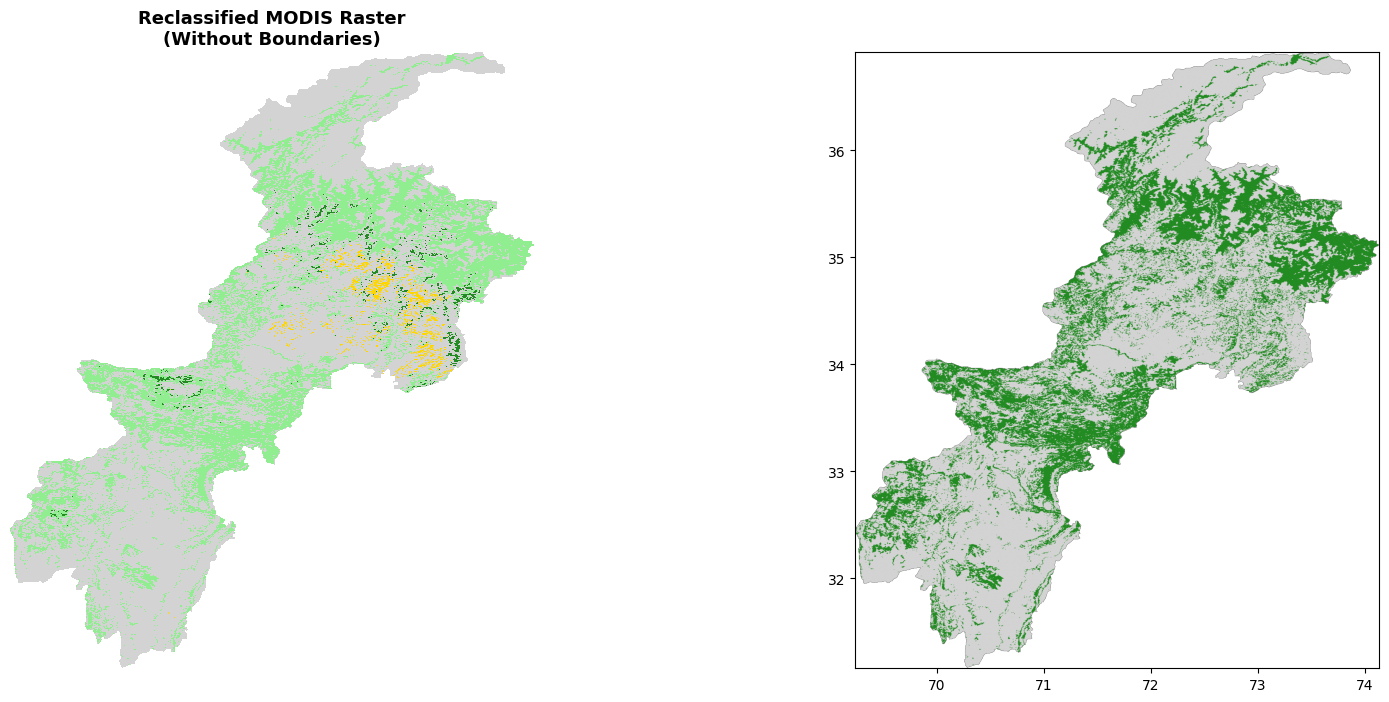

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from rasterio.plot import show

# Define colors and labels for each class
class_colors = {
    0: '#D3D3D3',   # Other - Light Gray
    1: '#228B22',   # Forest - Forest Green
    2: '#90EE90',   # Grasslands - Light Green
    3: '#FFD700',   # Croplands - Golden Yellow
}

# Create a colormap from defined class colors
cmap = mcolors.ListedColormap([class_colors[i] for i in sorted(class_colors)])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Reclassified Raster Only ---
with rasterio.open(reclass_path) as src:
    reclass_vis = src.read(1).astype(float)
    reclass_transform = src.transform
    reclass_vis[reclass_vis == 255] = np.nan  # mask nodata

im1 = axes[0].imshow(
    reclass_vis,
    cmap=cmap,
    norm=norm,
    interpolation='none'
)
axes[0].set_title('Reclassified MODIS Raster\n(Without Boundaries)', fontsize=13, fontweight='bold')
axes[0].axis('off')

# --- Plot 2: Reclassified Raster + Tehsil Boundaries ---
with rasterio.open(reclass_path) as src:
    show(reclass_vis, transform=reclass_transform, ax=axes[1], cmap=cmap, norm=norm)

gdf

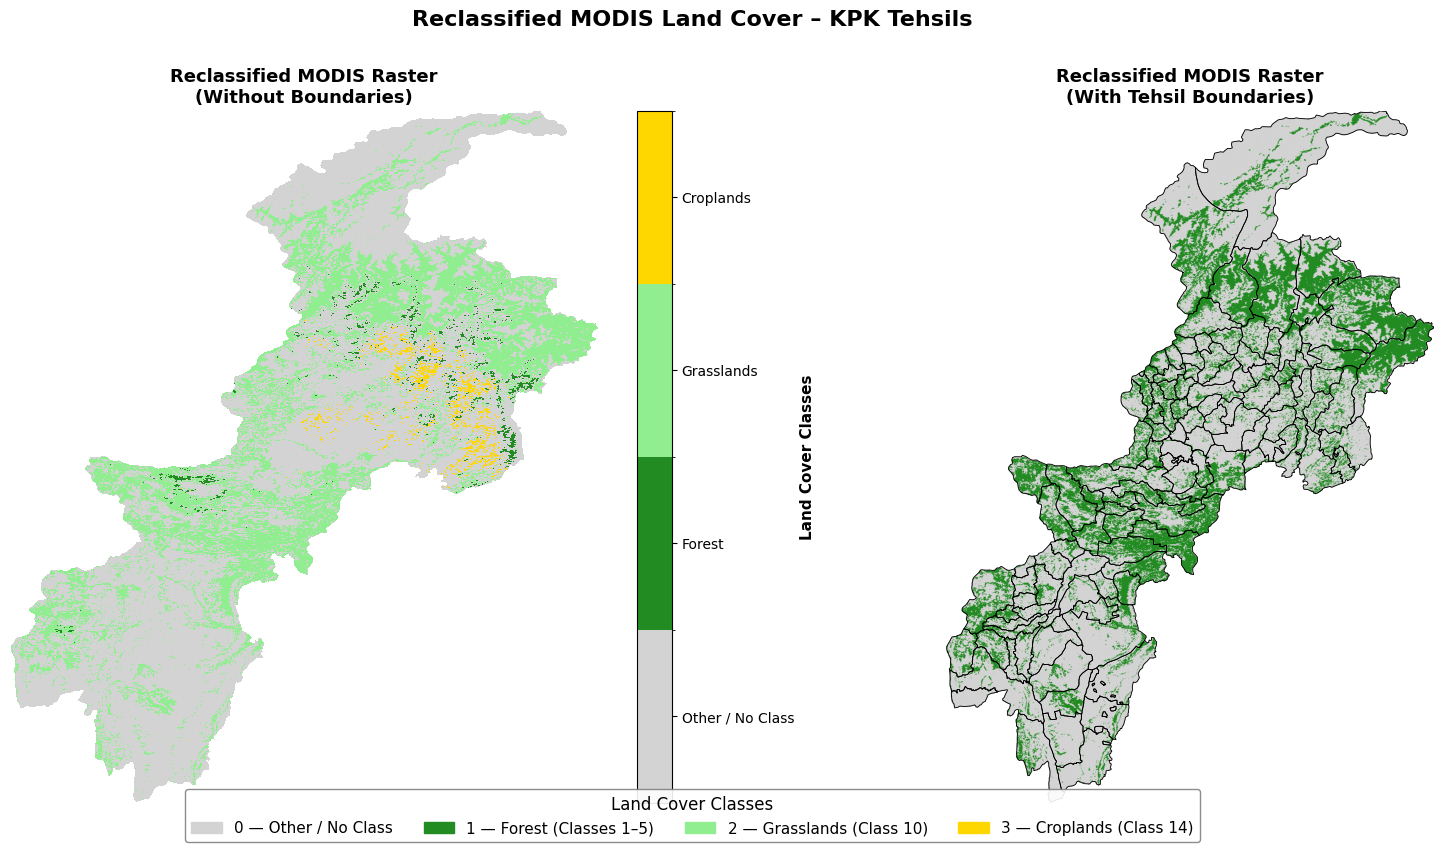

Reclassified visualization saved!


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
import rasterio
from rasterio.plot import show

# Define colors and labels for each class
class_colors = {
    0: '#D3D3D3',   # Other - Light Gray
    1: '#228B22',   # Forest - Forest Green
    2: '#90EE90',   # Grasslands - Light Green
    3: '#FFD700',   # Croplands - Golden Yellow
}

class_labels = {
    0: 'Other / No Class',
    1: 'Forest',
    2: 'Grasslands',
    3: 'Croplands'
}

# Create colormap
cmap = mcolors.ListedColormap([class_colors[i] for i in sorted(class_colors)])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Plot 1: Raster Only ---
with rasterio.open(reclass_path) as src:
    reclass_vis = src.read(1).astype(float)
    reclass_transform = src.transform
    reclass_vis[reclass_vis == 255] = np.nan  # Mask nodata

im1 = axes[0].imshow(
    reclass_vis,
    cmap=cmap,
    norm=norm,
    interpolation='none'
)

axes[0].set_title(
    'Reclassified MODIS Raster\n(Without Boundaries)',
    fontsize=13,
    fontweight='bold'
)
axes[0].axis('off')

# --- Add Colorbar Legend with Class Names ---
cbar = fig.colorbar(
    im1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04,
    ticks=[0, 1, 2, 3]
)

cbar.ax.set_yticklabels([
    class_labels[0],
    class_labels[1],
    class_labels[2],
    class_labels[3]
])

cbar.set_label('Land Cover Classes', fontsize=11, fontweight='bold')

# --- Plot 2: Raster + Tehsil Boundaries ---
with rasterio.open(reclass_path) as src:
    show(
        reclass_vis,
        transform=reclass_transform,
        ax=axes[1],
        cmap=cmap,
        norm=norm
    )

gdf.boundary.plot(
    ax=axes[1],
    color='black',
    linewidth=0.6,
    label='Tehsil Boundaries'
)

axes[1].set_title(
    'Reclassified MODIS Raster\n(With Tehsil Boundaries)',
    fontsize=13,
    fontweight='bold'
)
axes[1].axis('off')

# --- Shared Legend ---
legend_patches = [
    mpatches.Patch(color=class_colors[0], label='0 — Other / No Class'),
    mpatches.Patch(color=class_colors[1], label='1 — Forest (Classes 1–5)'),
    mpatches.Patch(color=class_colors[2], label='2 — Grasslands (Class 10)'),
    mpatches.Patch(color=class_colors[3], label='3 — Croplands (Class 14)')
]

fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=4,
    fontsize=11,
    frameon=True,
    framealpha=0.9,
    edgecolor='gray',
    bbox_to_anchor=(0.5, -0.04),
    title='Land Cover Classes',
    title_fontsize=12
)

plt.suptitle(
    'Reclassified MODIS Land Cover – KPK Tehsils',
    fontsize=16,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    'reclassified_viz.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Reclassified visualization saved!")

# Zonal Statistics

In [14]:
from rasterstats import zonal_stats
import pandas as pd

# Check the column name for tehsil names
print("Shapefile columns:", gdf.columns.tolist())
print(gdf.head())

Shapefile columns: ['OBJECTID', 'PROVINCE', 'DISTRICT', 'TEHSIL', 'SHAPE_Leng', 'Area_Sq_Km', 'Shape_Le_1', 'Shape_Area', 'geometry']
   OBJECTID PROVINCE       DISTRICT          TEHSIL  SHAPE_Leng  Area_Sq_Km  \
0       150     FATA  BAJAUR AGENCY  BAR CHAMARKAND    0.161485   16.632682   
1       151     FATA  BAJAUR AGENCY          BARANG    0.843519  266.801410   
2       152     FATA  BAJAUR AGENCY            KHAR    1.122599  276.057546   
3       153     FATA  BAJAUR AGENCY          MAMUND    0.760798  265.629641   
4       154     FATA  BAJAUR AGENCY         NAWAGAI    0.529303  126.869064   

   Shape_Le_1  Shape_Area                                           geometry  
0    0.161485    0.001637  POLYGON ((71.22452 34.7539, 71.22499 34.75334,...  
1    0.843519    0.026209  POLYGON ((71.58568 34.72182, 71.58604 34.72165...  
2    1.122599    0.027156  POLYGON ((71.62753 34.80824, 71.62794 34.80821...  
3    0.760798    0.026165  POLYGON ((71.48933 34.8027, 71.48888 34.80227,..

In [16]:
import pandas as pd
from rasterstats import zonal_stats

# Column containing tehsil names
tehsil_col = 'TEHSIL'   # Change if your shapefile uses another column

# Run zonal statistics
stats = zonal_stats(
    gdf,
    reclass_path,
    stats=['min', 'max', 'mean', 'majority', 'minority'],
    nodata=255,
    geojson_out=False
)

# Create DataFrame
results_df = pd.DataFrame(stats)

# Add Tehsil Names
results_df.insert(0, 'Tehsil', gdf[tehsil_col].values)

# Rename columns for cleaner presentation
results_df.columns = [
    'Tehsil',
    'Minimum Class',
    'Maximum Class',
    'Mean Class Value',
    'Majority Class',
    'Minority Class'
]

# Round mean values
results_df['Mean Class Value'] = results_df['Mean Class Value'].round(2)

# Sort alphabetically by tehsil
results_df = results_df.sort_values(by='Tehsil')

# Reset index
results_df.reset_index(drop=True, inplace=True)

# Display full table
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n===== Zonal Statistics for All Tehsils =====\n")
print(results_df.to_string(index=False))

# Optional: Save to CSV
results_df.to_csv('tehsil_zonal_statistics.csv', index=False)

print("\nCSV file saved as: tehsil_zonal_statistics.csv")


===== Zonal Statistics for All Tehsils =====

             Tehsil  Minimum Class  Maximum Class  Mean Class Value  Majority Class  Minority Class
         ABBOTTABAD            0.0            3.0              0.52             0.0             2.0
            ADENZAI            0.0            3.0              0.37             0.0             1.0
               ALAI            0.0            3.0              1.14             2.0             1.0
             ALPURI            0.0            3.0              0.72             0.0             1.0
   AMBAR UTMAN KHEL            0.0            2.0              1.01             2.0             1.0
            BABUZAI            0.0            3.0              0.65             0.0             1.0
            BAHRAIN            0.0            3.0              1.06             2.0             3.0
            BALAKOT            0.0            3.0              1.36             2.0             3.0
    BANDA DAUD SHAH            0.0            2.0    

In [19]:
import pandas as pd
from rasterstats import zonal_stats

# Column containing tehsil names
tehsil_col = 'TEHSIL'   # Change if your shapefile uses another column

# Run zonal statistics
stats = zonal_stats(
    gdf,
    reclass_path,
    stats=['min', 'max', 'mean', 'majority', 'minority'],
    nodata=255,
    geojson_out=False
)

# Create DataFrame
results_df = pd.DataFrame(stats)

# Add Tehsil Names
results_df.insert(0, 'Tehsil', gdf[tehsil_col].values)

# Rename columns for cleaner presentation
results_df.columns = [
    'Tehsil',
    'Minimum Class',
    'Maximum Class',
    'Mean Class Value',
    'Majority Class',
    'Minority Class'
]

# Round mean values
results_df['Mean Class Value'] = results_df['Mean Class Value'].round(2)

# Sort alphabetically by tehsil
results_df = results_df.sort_values(by='Tehsil')

# Reset index
results_df.reset_index(drop=True, inplace=True)

# -------------------------------
# BETTER TABLE FORMATTING SECTION
# -------------------------------

# Set display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.colheader_justify', 'center')

# Create aligned table
formatted_table = results_df.to_string(
    index=False,
    justify='center',
    col_space=18
)

print("\n" + "=" * 120)
print("                    ZONAL STATISTICS FOR ALL TEHSILS")
print("=" * 120)
print(formatted_table)
print("=" * 120)

# Optional: Save to CSV
results_df.to_csv('tehsil_zonal_statistics.csv', index=False)

print("\nCSV file saved as: tehsil_zonal_statistics.csv")


                    ZONAL STATISTICS FOR ALL TEHSILS
       Tehsil          Minimum Class      Maximum Class    Mean Class Value    Majority Class     Minority Class  
         ABBOTTABAD        0.0                3.0                0.52               0.0                2.0        
            ADENZAI        0.0                3.0                0.37               0.0                1.0        
               ALAI        0.0                3.0                1.14               2.0                1.0        
             ALPURI        0.0                3.0                0.72               0.0                1.0        
   AMBAR UTMAN KHEL        0.0                2.0                1.01               2.0                1.0        
            BABUZAI        0.0                3.0                0.65               0.0                1.0        
            BAHRAIN        0.0                3.0                1.06               2.0                3.0        
            BALAKOT       

Shapefile columns: ['OBJECTID', 'PROVINCE', 'DISTRICT', 'TEHSIL', 'SHAPE_Leng', 'Area_Sq_Km', 'Shape_Le_1', 'Shape_Area', 'geometry']

📊 Overall Zonal Stats (Reclassified Raster):
       Tehsil      min  max    mean    count
0  BAR CHAMARKAND  0.0  2.0  0.715789    95 
1          BARANG  0.0  2.0  0.747347  1508 
2            KHAR  0.0  2.0  0.658568  1564 
3          MAMUND  0.0  3.0  0.831229  1505 
4         NAWAGAI  0.0  2.0  1.157163   719 
5        SALARZAI  0.0  2.0  0.531458  1351 
6      UTMAN KHEL  0.0  2.0  0.617861   963 
7        FR BANNU  0.0  2.0  0.171191  4568 
8     FR D.I.KHAN  0.0  2.0  0.415833  9095 
9        FR KOHAT  0.0  2.0  1.219131  2624 

✅ Class 0 — Other:
       Tehsil      Other_total_pixels  Other_pixel_count  Other_pct (%)
0  BAR CHAMARKAND           61                61.0            100.0    
1          BARANG          944               944.0            100.0    
2            KHAR         1049              1049.0            100.0    
3          MAMUND

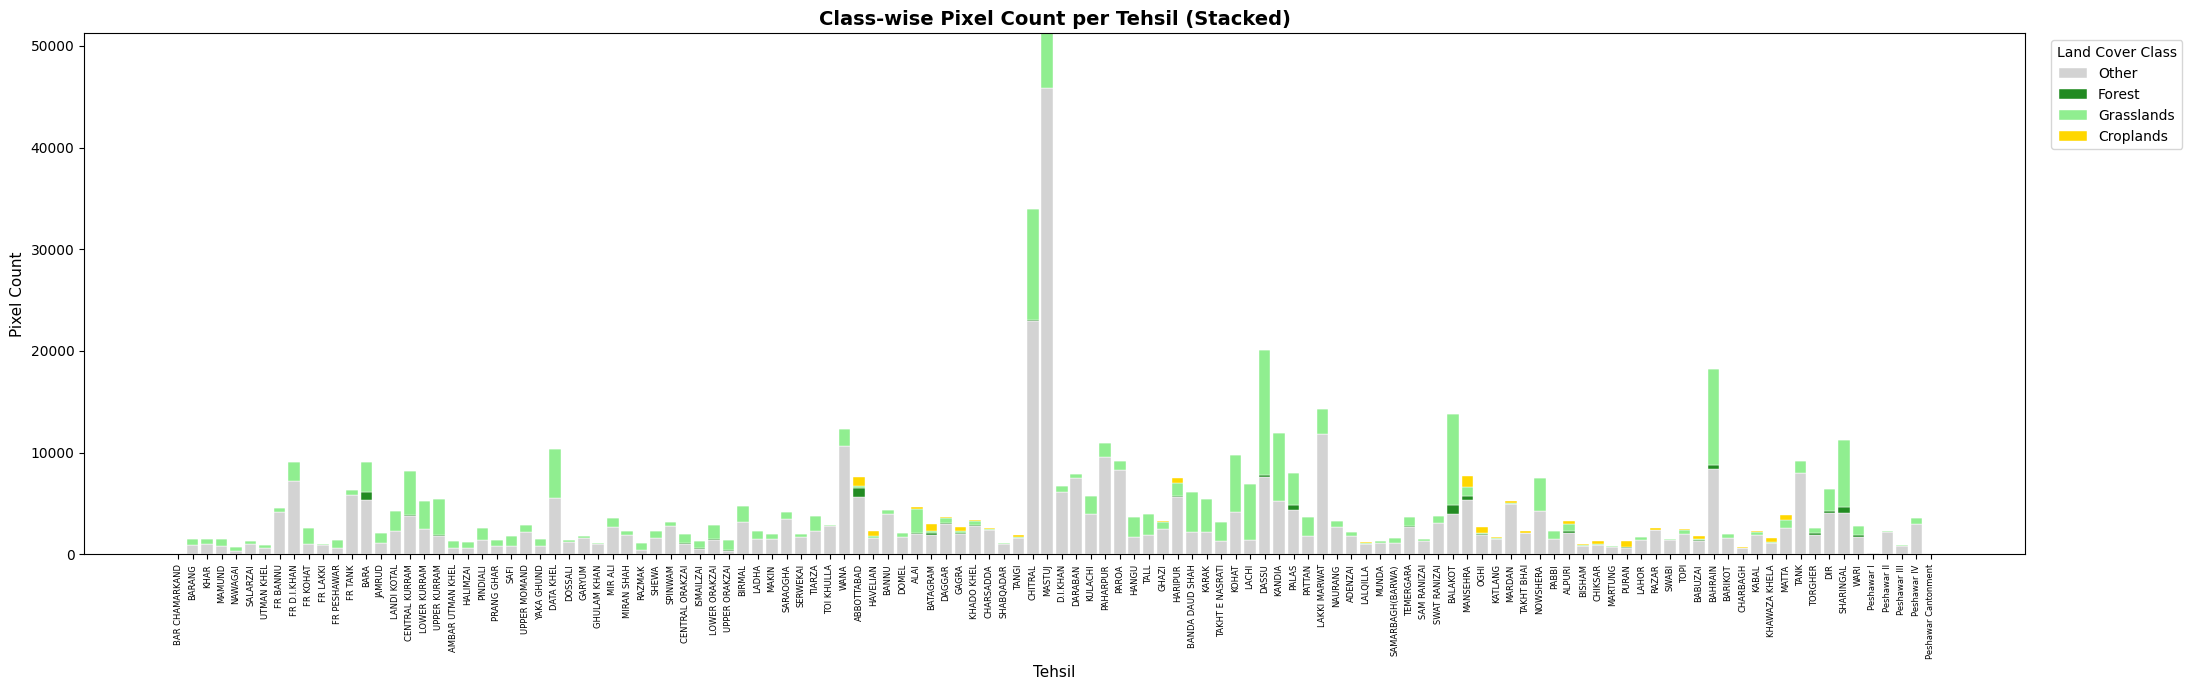

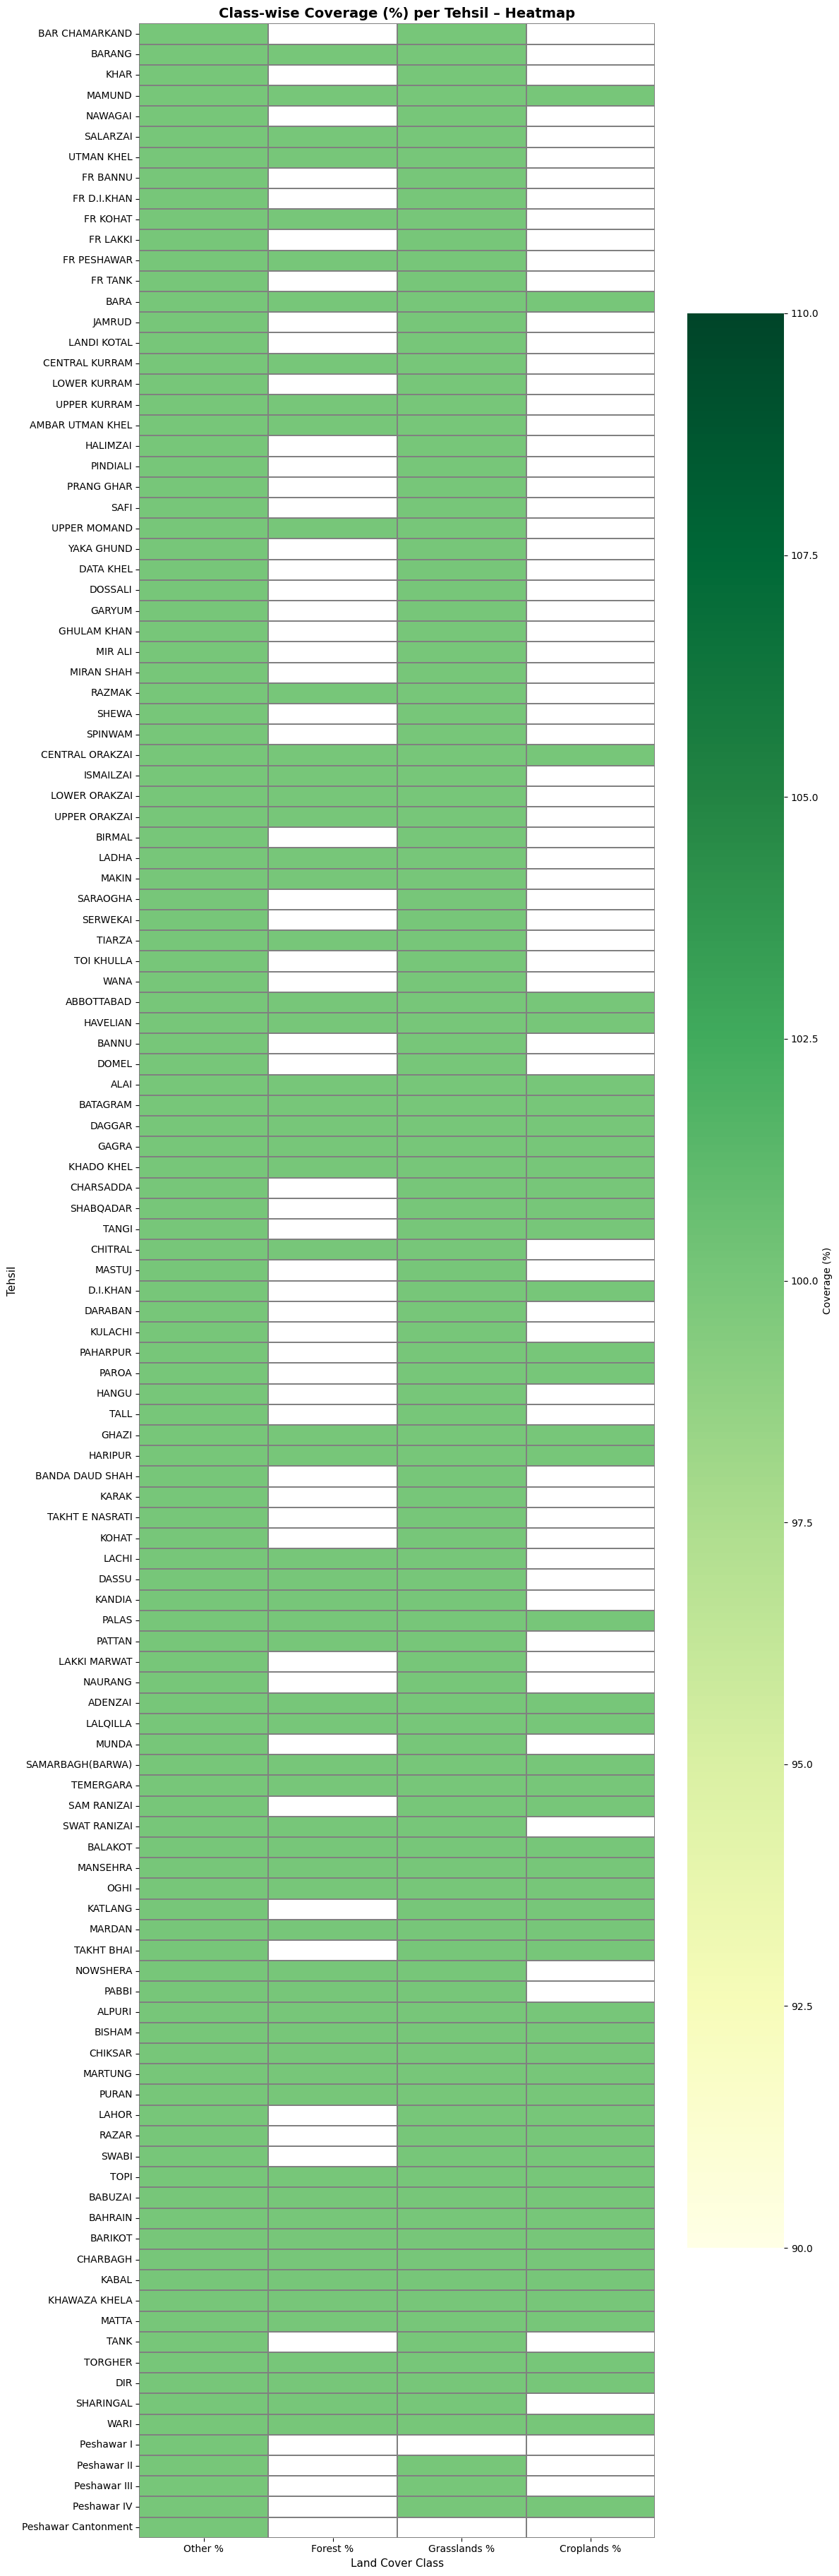

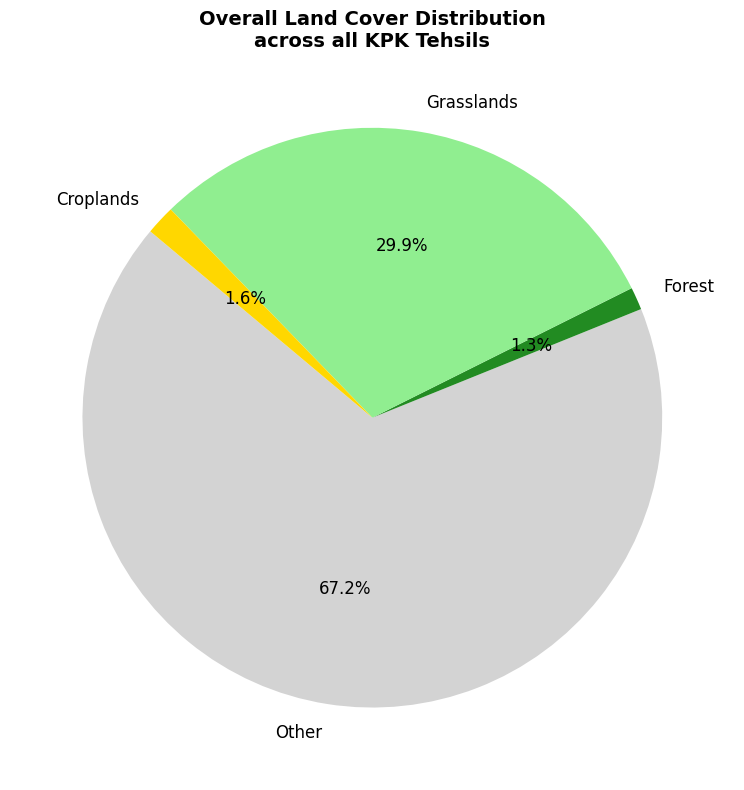


✅ CSVs saved: classwise_zonal_stats.csv  |  classwise_pixel_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
from rasterstats import zonal_stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Check column name ──────────────────────────────────────────────────────────
print("Shapefile columns:", gdf.columns.tolist())
tehsil_col = 'TEHSIL'   # ← change if your column name is different

# ══════════════════════════════════════════════════════════════════════════════
# 1.  OVERALL ZONAL STATS  (on reclassified raster)
# ══════════════════════════════════════════════════════════════════════════════
overall_stats = zonal_stats(
    gdf,
    reclass_path,
    stats=['min', 'max', 'mean', 'count'],
    nodata=255
)

overall_df = pd.DataFrame(overall_stats)
overall_df.insert(0, 'Tehsil', gdf[tehsil_col].values)
print("\n📊 Overall Zonal Stats (Reclassified Raster):")
print(overall_df.head(10))

# ══════════════════════════════════════════════════════════════════════════════
# 2.  CLASS-WISE ZONAL STATS
#     Strategy: mask raster to keep only pixels of each class,
#               then run zonal_stats per tehsil for that class mask.
# ══════════════════════════════════════════════════════════════════════════════

classes = {
    0: 'Other',
    1: 'Forest',
    2: 'Grasslands',
    3: 'Croplands'
}

class_dfs = {}   # store one dataframe per class

for class_val, class_name in classes.items():

    # --- build a binary mask raster for this class ---
    mask_path = f'class_{class_val}_mask.tif'

    with rasterio.open(reclass_path) as src:
        data   = src.read(1).astype(np.float32)
        meta   = src.meta.copy()

        # pixels belonging to this class → 1, everything else → nodata
        binary = np.where(data == class_val, 1, 255).astype(np.uint8)

    meta.update({'dtype': 'uint8', 'nodata': 255})
    with rasterio.open(mask_path, 'w', **meta) as dst:
        dst.write(binary, 1)

    # --- zonal stats on the binary mask ---
    stats = zonal_stats(
        gdf,
        mask_path,
        stats=['count', 'sum'],   # sum = pixel count for this class per tehsil
        nodata=255
    )

    df = pd.DataFrame(stats)
    df.insert(0, 'Tehsil', gdf[tehsil_col].values)

    # pixel_count = number of pixels of this class inside each tehsil
    df.rename(columns={'sum': f'{class_name}_pixel_count',
                        'count': f'{class_name}_total_pixels'}, inplace=True)

    # percentage coverage
    df[f'{class_name}_pct (%)'] = (
        df[f'{class_name}_pixel_count'] / df[f'{class_name}_total_pixels'] * 100
    ).round(2)

    class_dfs[class_name] = df
    print(f"\n✅ Class {class_val} — {class_name}:")
    print(df[[col for col in df.columns]].head(5))

# ══════════════════════════════════════════════════════════════════════════════
# 3.  MERGE ALL CLASS STATS INTO ONE TABLE
# ══════════════════════════════════════════════════════════════════════════════
merged_df = class_dfs['Other'][['Tehsil']].copy()

for class_name, df in class_dfs.items():
    cols = [c for c in df.columns if c != 'Tehsil']
    merged_df = merged_df.merge(df[['Tehsil'] + cols], on='Tehsil', how='left')

print("\n📋 Merged Class-wise Zonal Stats Table:")
print(merged_df.head(10))

# ══════════════════════════════════════════════════════════════════════════════
# 4.  SUMMARY TABLE  – pixel counts only (clean view)
# ══════════════════════════════════════════════════════════════════════════════
summary_cols = ['Tehsil'] + [f'{n}_pixel_count' for n in classes.values()]
summary_df   = merged_df[summary_cols].copy()
summary_df.columns = ['Tehsil', 'Other', 'Forest', 'Grasslands', 'Croplands']

print("\n📌 Pixel Count Summary per Tehsil:")
print(summary_df.head(10))

# ══════════════════════════════════════════════════════════════════════════════
# 5.  VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════

class_colors = ['#D3D3D3', '#228B22', '#90EE90', '#FFD700']

# ── Plot 1: Stacked Bar – pixel counts per tehsil ─────────────────────────────
fig, ax = plt.subplots(figsize=(22, 7))

bottom = np.zeros(len(summary_df))
for col, color in zip(['Other', 'Forest', 'Grasslands', 'Croplands'], class_colors):
    values = summary_df[col].fillna(0).values
    ax.bar(summary_df['Tehsil'], values, bottom=bottom, label=col,
           color=color, edgecolor='white', linewidth=0.3)
    bottom += values

ax.set_title('Class-wise Pixel Count per Tehsil (Stacked)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tehsil', fontsize=11)
ax.set_ylabel('Pixel Count', fontsize=11)
ax.legend(title='Land Cover Class', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig('classwise_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Percentage heatmap per tehsil ─────────────────────────────────────
pct_cols  = [f'{n}_pct (%)' for n in classes.values()]
pct_df    = merged_df[['Tehsil'] + pct_cols].copy()
pct_df.columns = ['Tehsil', 'Other %', 'Forest %', 'Grasslands %', 'Croplands %']
pct_df    = pct_df.set_index('Tehsil')

fig, ax = plt.subplots(figsize=(12, max(8, len(pct_df) * 0.3)))
sns.heatmap(
    pct_df,
    cmap='YlGn',
    annot=False,
    linewidths=0.3,
    linecolor='gray',
    ax=ax,
    cbar_kws={'label': 'Coverage (%)'}
)
ax.set_title('Class-wise Coverage (%) per Tehsil – Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Land Cover Class', fontsize=11)
ax.set_ylabel('Tehsil', fontsize=11)
plt.tight_layout()
plt.savefig('classwise_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Total pixel count per class (pie chart) ───────────────────────────
class_totals = summary_df[['Other','Forest','Grasslands','Croplands']].sum()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    class_totals,
    labels=class_totals.index,
    colors=class_colors,
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12}
)
ax.set_title('Overall Land Cover Distribution\nacross all KPK Tehsils',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('classwise_pie.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 6.  SAVE ALL RESULTS TO CSV
# ══════════════════════════════════════════════════════════════════════════════
merged_df.to_csv('classwise_zonal_stats.csv', index=False)
summary_df.to_csv('classwise_pixel_summary.csv', index=False)
print("\n✅ CSVs saved: classwise_zonal_stats.csv  |  classwise_pixel_summary.csv")

# download
files.download('classwise_zonal_stats.csv')
files.download('classwise_pixel_summary.csv')


✅ Class 0 — Other:
    Tehsil      Other_pixel_count  Other_pct (%)  Other_min  Other_max  Other_mean
BAR CHAMARKAND          61            100.0         7.0         9.0       8.1148  
        BARANG         944            100.0         6.0        12.0       8.7977  
          KHAR        1049            100.0         7.0        12.0      10.9609  
        MAMUND         880            100.0         7.0        12.0      11.2932  
       NAWAGAI         303            100.0         6.0        12.0       9.0000  

✅ Class 1 — Forest:
    Tehsil      Forest_pixel_count  Forest_pct (%)  Forest_min  Forest_max  Forest_mean
BAR CHAMARKAND          0                 NaN          NaN         NaN         NaN     
        BARANG          1               100.0          4.0         4.0         4.0     
          KHAR          0                 NaN          NaN         NaN         NaN     
        MAMUND          1               100.0          1.0         1.0         1.0     
       NAWAGAI       

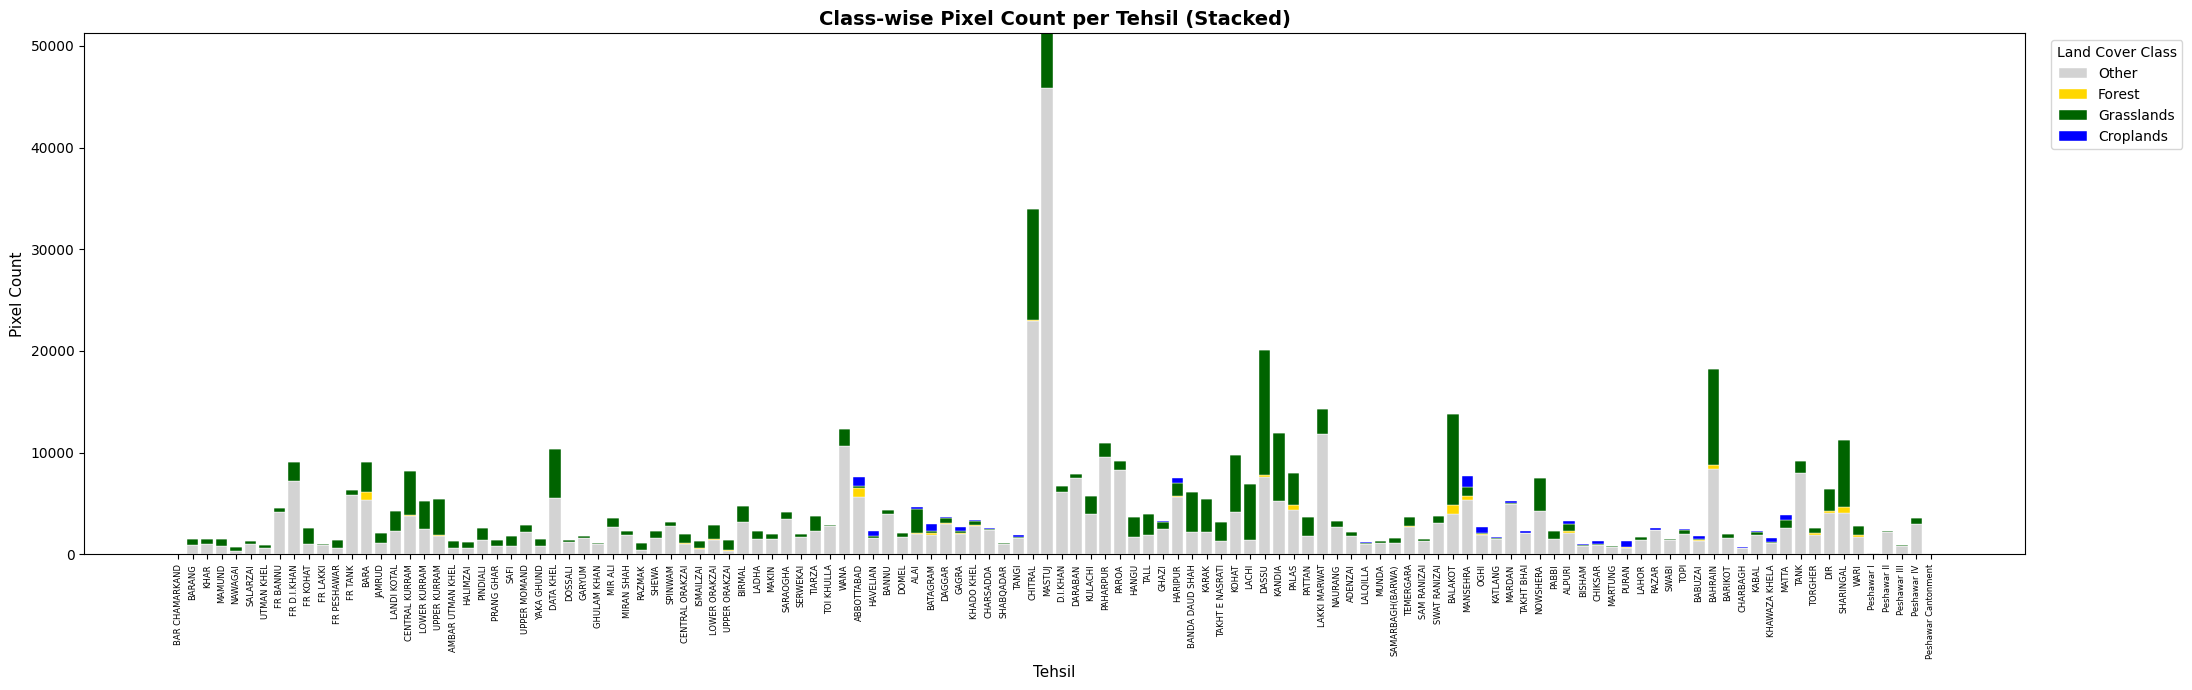

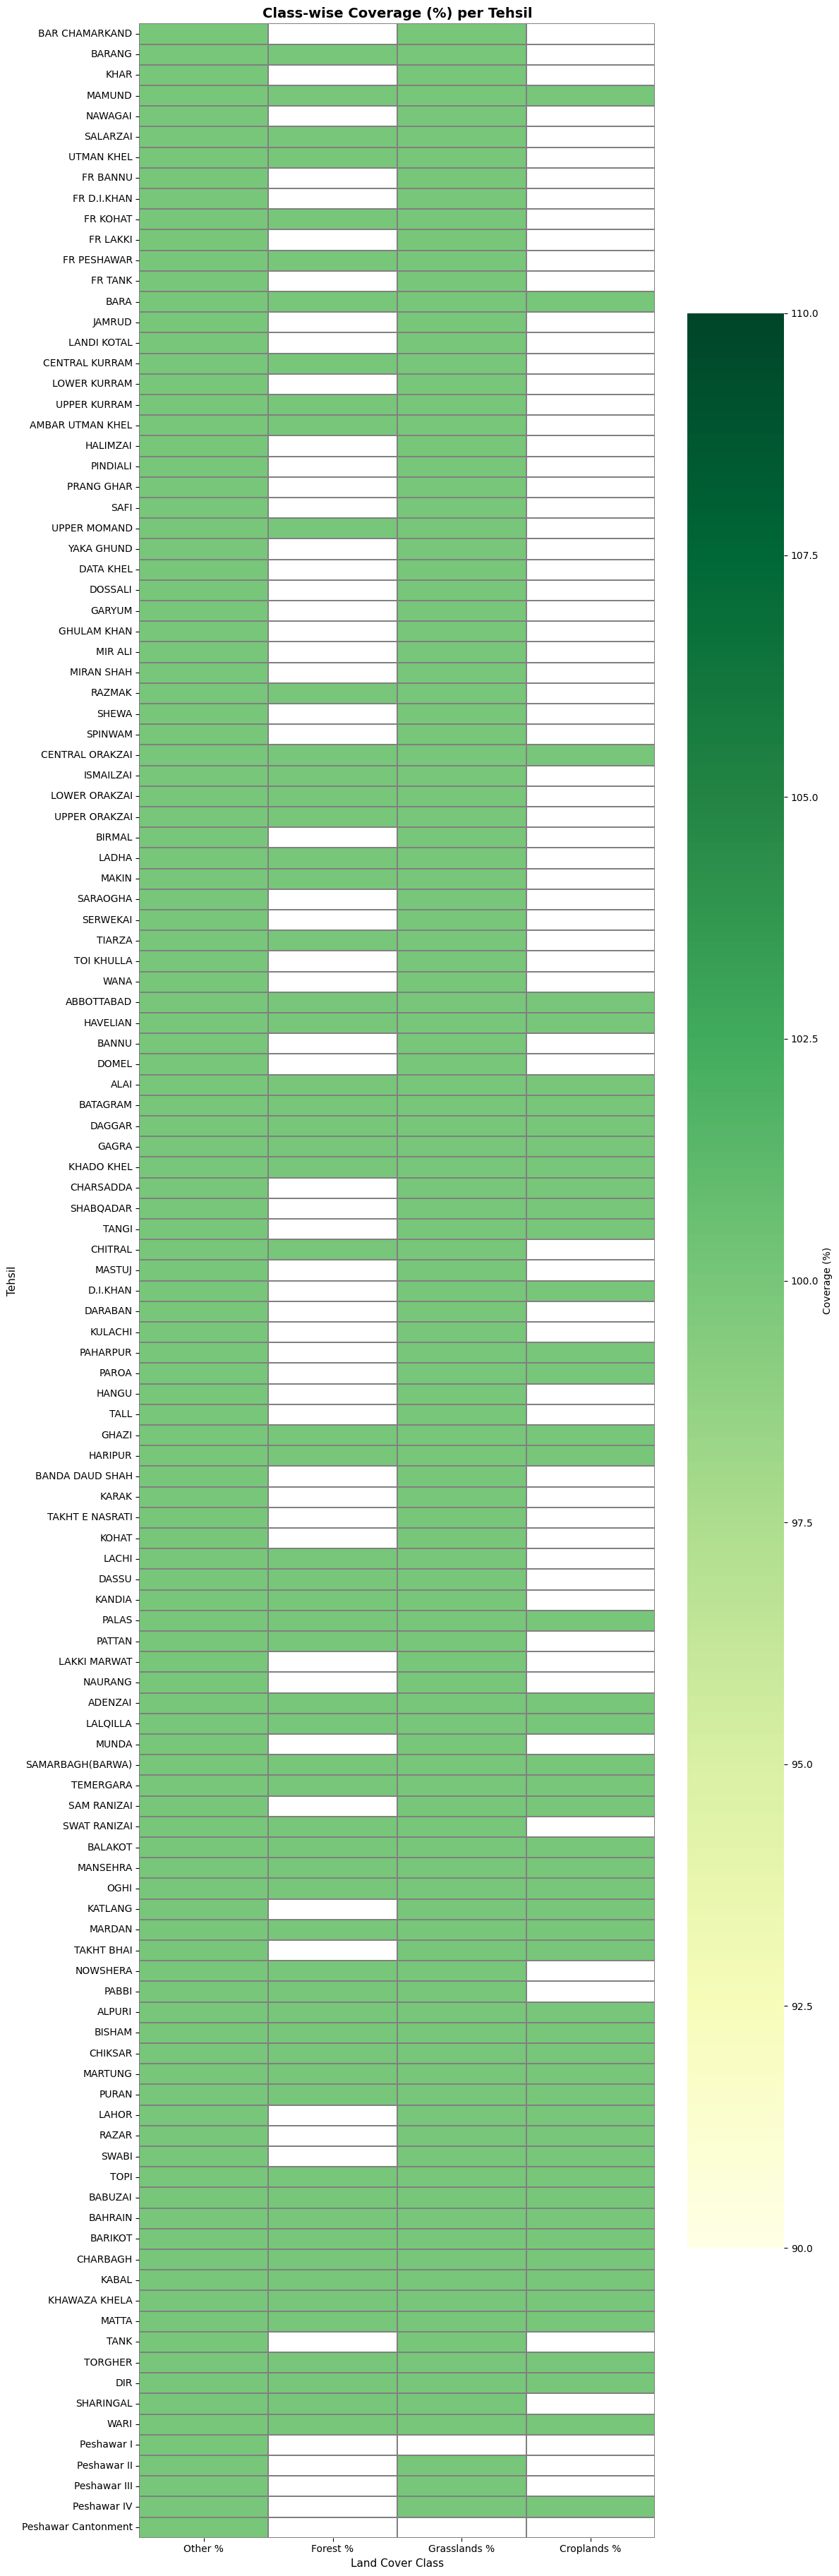

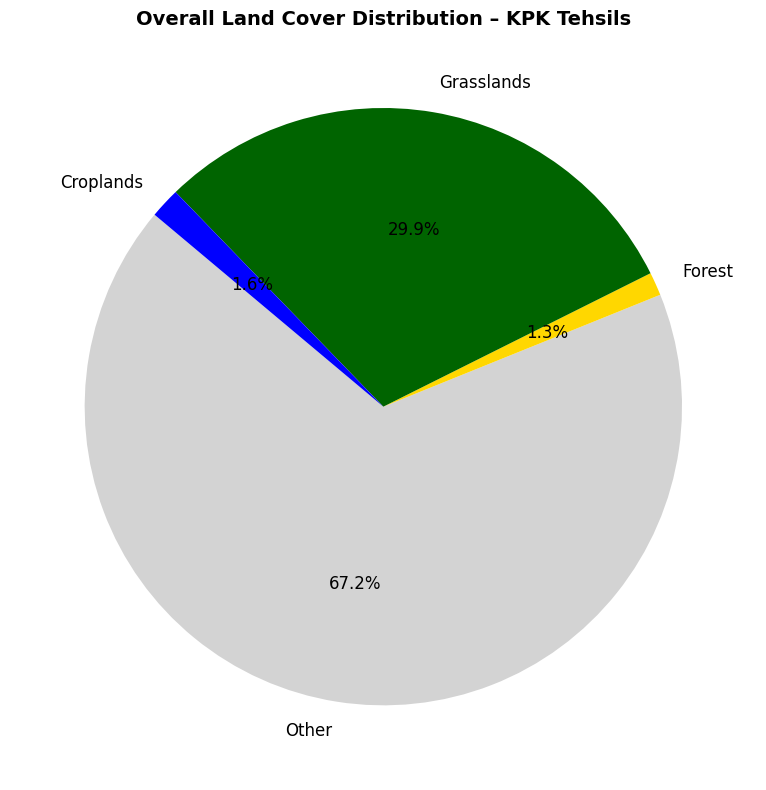

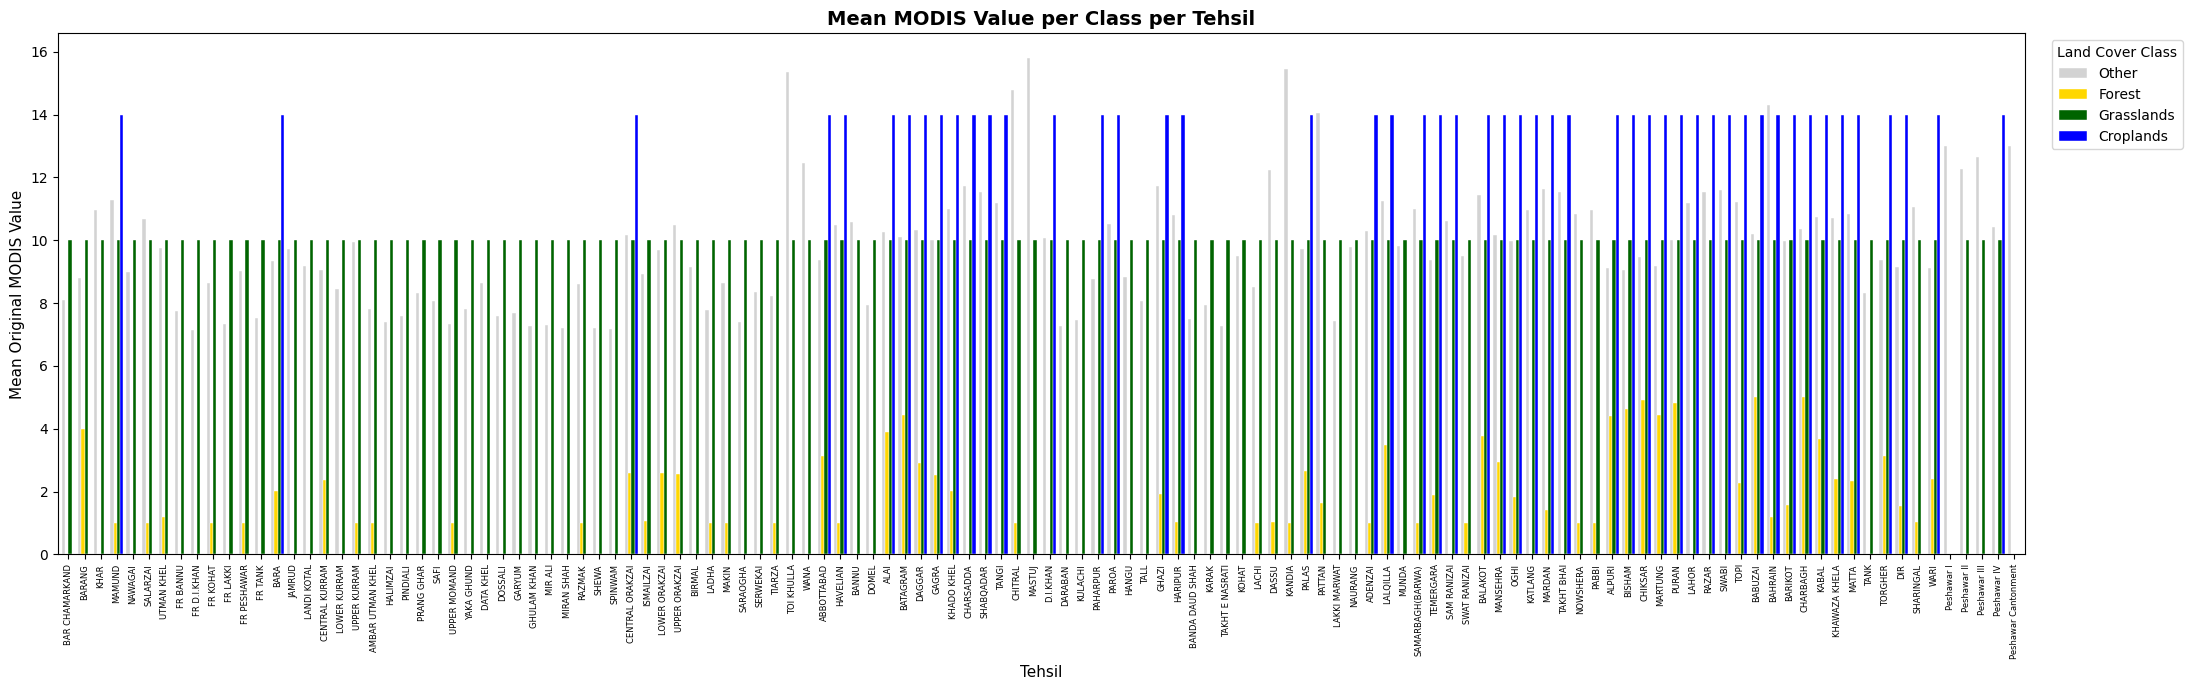

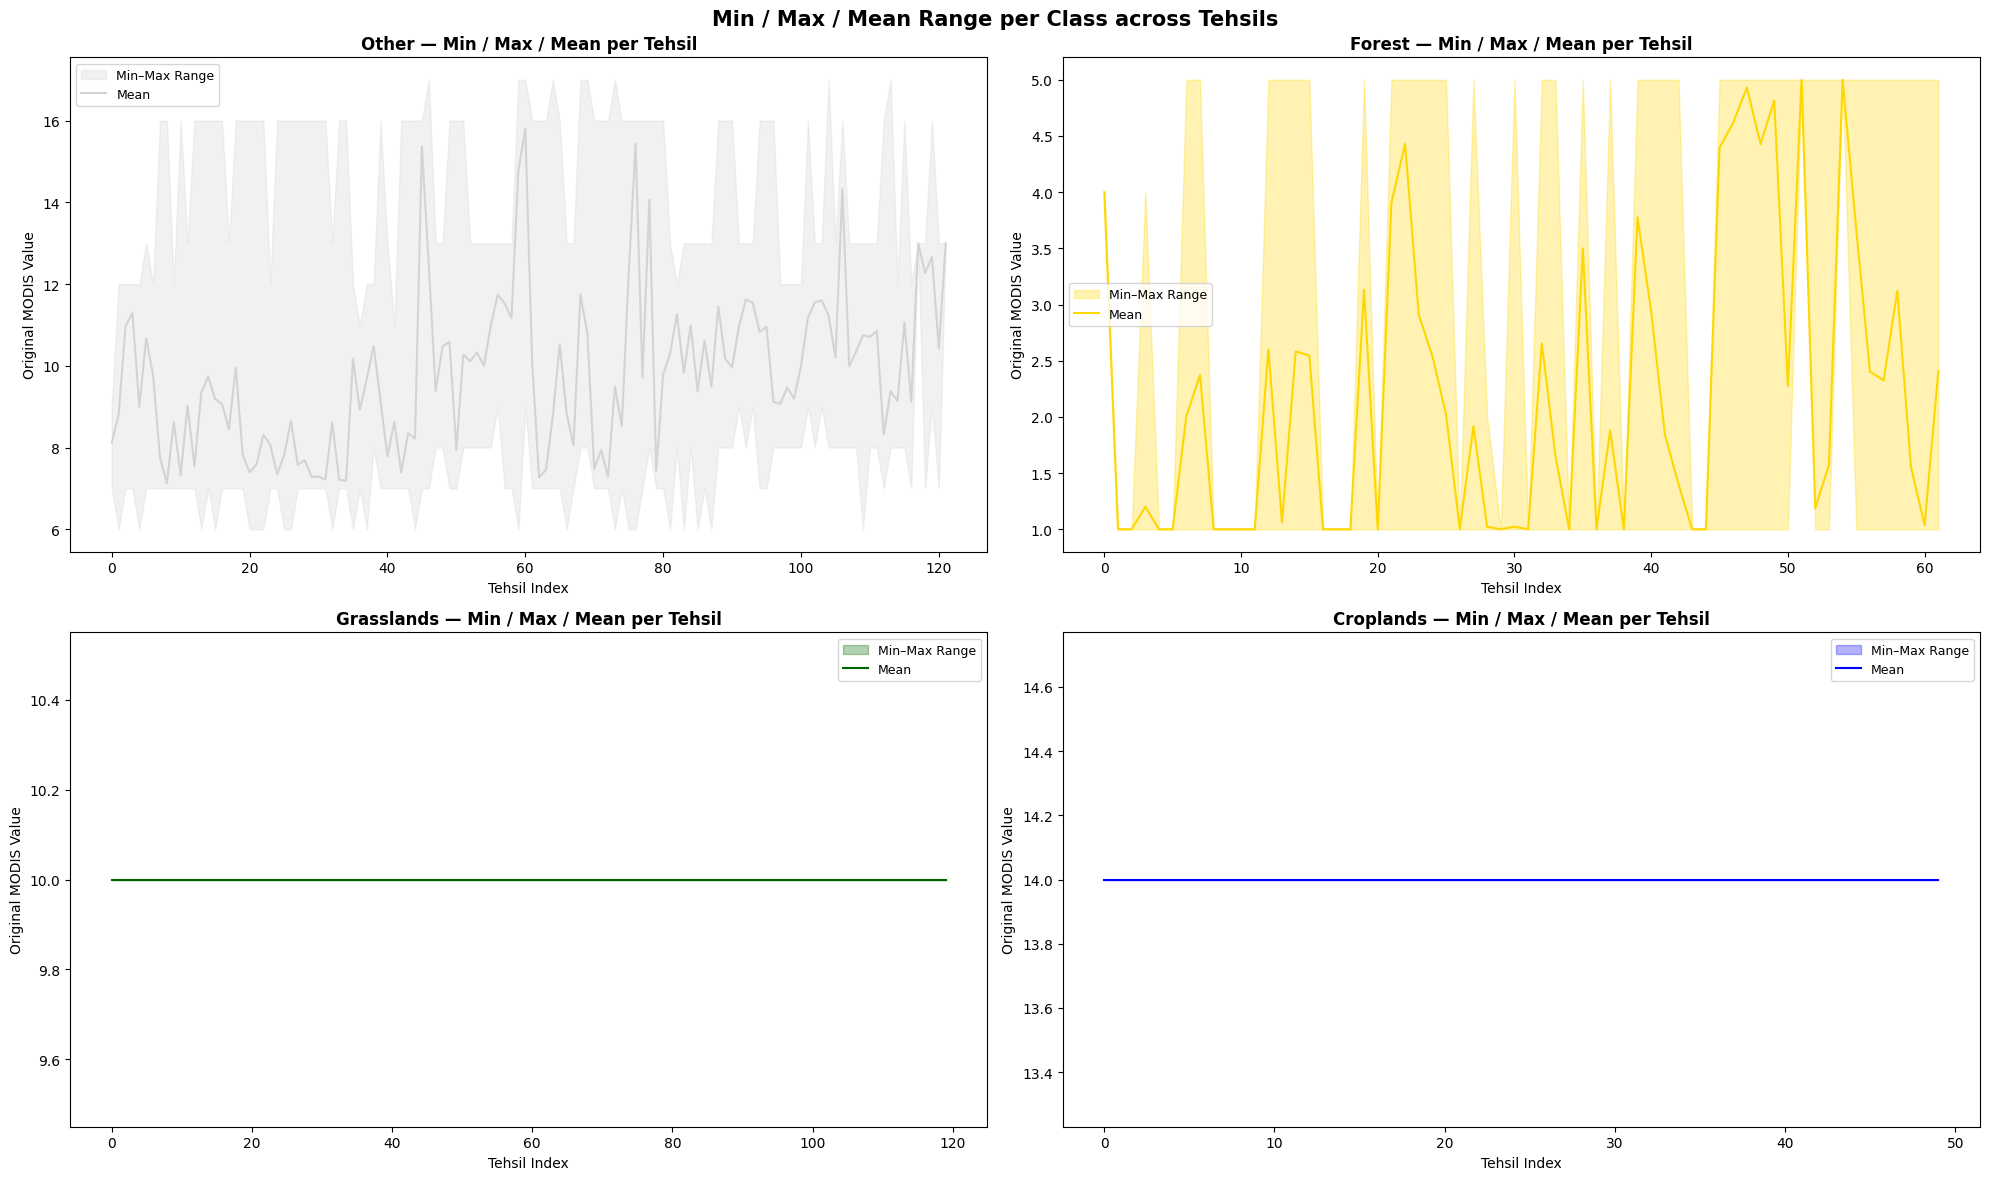


✅ All CSVs saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from rasterstats import zonal_stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

tehsil_col = 'TEHSIL'   # ← change if your column name is different

classes = {
    0: 'Other',
    1: 'Forest',
    2: 'Grasslands',
    3: 'Croplands'
}

# Reclassification mapping (same as before)
# Classes 1–5 → 1 (Forest), 10 → 2 (Grasslands), 14 → 3 (Croplands), else → 0
def get_original_classes(class_val):
    """Return the original MODIS class values that map to this reclassified value."""
    mapping = {
        0: [c for c in range(0, 18) if c not in [1,2,3,4,5,10,14]],  # all others
        1: [1, 2, 3, 4, 5],    # Forest
        2: [10],                # Grasslands
        3: [14],                # Croplands
    }
    return mapping[class_val]

class_dfs = {}

for class_val, class_name in classes.items():

    binary_path = f'class_{class_val}_binary.tif'
    orig_vals_path = f'class_{class_val}_origvals.tif'

    original_classes = get_original_classes(class_val)

    with rasterio.open(clipped_path) as src:        # ← original clipped raster
        orig_data = src.read(1).astype(np.float32)
        meta = src.meta.copy()
        nodata_val = src.nodata if src.nodata else 255

    with rasterio.open(reclass_path) as src:        # ← reclassified raster
        reclass_data = src.read(1).astype(np.float32)

    # ── Binary mask: 1 where reclassified == class_val, else 255 ──────────────
    binary = np.where(reclass_data == class_val, 1, 255).astype(np.uint8)
    meta_bin = meta.copy()
    meta_bin.update({'dtype': 'uint8', 'nodata': 255})
    with rasterio.open(binary_path, 'w', **meta_bin) as dst:
        dst.write(binary, 1)

    # ── Original value mask: keep original pixel values where class matches ───
    # This gives meaningful min/max/mean from the raw MODIS values
    orig_masked = np.where(
        reclass_data == class_val,
        orig_data,
        np.nan
    ).astype(np.float32)

    meta_val = meta.copy()
    meta_val.update({'dtype': 'float32', 'nodata': -9999})
    orig_masked_save = np.where(np.isnan(orig_masked), -9999, orig_masked).astype(np.float32)
    with rasterio.open(orig_vals_path, 'w', **meta_val) as dst:
        dst.write(orig_masked_save, 1)

    # ── Zonal stats: pixel count from binary mask ──────────────────────────────
    stats_count = zonal_stats(
        gdf,
        binary_path,
        stats=['count', 'sum'],
        nodata=255
    )

    # ── Zonal stats: min/max/mean from original value mask ────────────────────
    stats_vals = zonal_stats(
        gdf,
        orig_vals_path,
        stats=['min', 'max', 'mean'],
        nodata=-9999
    )

    # ── Build dataframe ────────────────────────────────────────────────────────
    df_count = pd.DataFrame(stats_count)
    df_vals  = pd.DataFrame(stats_vals)

    df = pd.DataFrame()
    df['Tehsil']                     = gdf[tehsil_col].values
    df[f'{class_name}_pixel_count']  = df_count['sum'].fillna(0).astype(int)
    df[f'{class_name}_total_pixels'] = df_count['count'].fillna(0).astype(int)
    df[f'{class_name}_pct (%)']      = (
        df[f'{class_name}_pixel_count'] /
        df[f'{class_name}_total_pixels'] * 100
    ).round(2)
    df[f'{class_name}_min']          = df_vals['min'].round(4)
    df[f'{class_name}_max']          = df_vals['max'].round(4)
    df[f'{class_name}_mean']         = df_vals['mean'].round(4)

    class_dfs[class_name] = df

    print(f"\n✅ Class {class_val} — {class_name}:")
    print(df[['Tehsil',
              f'{class_name}_pixel_count',
              f'{class_name}_pct (%)',
              f'{class_name}_min',
              f'{class_name}_max',
              f'{class_name}_mean']].head(5).to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# MERGE ALL CLASS STATS INTO ONE TABLE
# ══════════════════════════════════════════════════════════════════════════════
merged_df = class_dfs['Other'][['Tehsil']].copy()

for class_name, df in class_dfs.items():
    cols = [c for c in df.columns if c != 'Tehsil']
    merge_cols = ['Tehsil'] + cols
    merged_df = merged_df.merge(df[merge_cols], on='Tehsil', how='left')

print("\n📋 Full Merged Table (first 5 rows):")
print(merged_df.head(5).to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# PIXEL COUNT SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════
summary_cols = ['Tehsil'] + [f'{n}_pixel_count' for n in classes.values()]
summary_df   = merged_df[summary_cols].copy()
summary_df.columns = ['Tehsil', 'Other', 'Forest', 'Grasslands', 'Croplands']

print("\n📌 Pixel Count Summary:")
print(summary_df.head(10).to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# LONG FORMAT TABLE  – one row per tehsil per class
# ══════════════════════════════════════════════════════════════════════════════
stat_rows = []
for class_name in classes.values():
    for _, row in merged_df.iterrows():
        stat_rows.append({
            'Tehsil'      : row['Tehsil'],
            'Class'       : class_name,
            'Pixel_Count' : row.get(f'{class_name}_pixel_count', np.nan),
            'Pct (%)'     : row.get(f'{class_name}_pct (%)', np.nan),
            'Min'         : row.get(f'{class_name}_min', np.nan),
            'Max'         : row.get(f'{class_name}_max', np.nan),
            'Mean'        : row.get(f'{class_name}_mean', np.nan),
        })

stats_long_df = pd.DataFrame(stat_rows)
print("\n📊 Long Format — Min/Max/Mean per Class per Tehsil:")
print(stats_long_df.head(12).to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
class_colors = ['#D3D3D3', '#FFD700', '#006400', '#0000FF']

# ── Plot 1: Stacked Bar ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 7))
bottom = np.zeros(len(summary_df))
for col, color in zip(['Other', 'Forest', 'Grasslands', 'Croplands'], class_colors):
    values = summary_df[col].fillna(0).values
    ax.bar(summary_df['Tehsil'], values, bottom=bottom,
           label=col, color=color, edgecolor='white', linewidth=0.3)
    bottom += values
ax.set_title('Class-wise Pixel Count per Tehsil (Stacked)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tehsil', fontsize=11)
ax.set_ylabel('Pixel Count', fontsize=11)
ax.legend(title='Land Cover Class', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig('classwise_stacked_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Heatmap ───────────────────────────────────────────────────────────
pct_cols = [f'{n}_pct (%)' for n in classes.values()]
pct_df   = merged_df[['Tehsil'] + pct_cols].copy()
pct_df.columns = ['Tehsil', 'Other %', 'Forest %', 'Grasslands %', 'Croplands %']
pct_df   = pct_df.set_index('Tehsil')

fig, ax = plt.subplots(figsize=(12, max(8, len(pct_df) * 0.3)))
sns.heatmap(pct_df, cmap='YlGn', annot=False, linewidths=0.3,
            linecolor='gray', ax=ax, cbar_kws={'label': 'Coverage (%)'})
ax.set_title('Class-wise Coverage (%) per Tehsil', fontsize=14, fontweight='bold')
ax.set_xlabel('Land Cover Class', fontsize=11)
ax.set_ylabel('Tehsil', fontsize=11)
plt.tight_layout()
plt.savefig('classwise_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Pie Chart ─────────────────────────────────────────────────────────
class_totals = summary_df[['Other', 'Forest', 'Grasslands', 'Croplands']].sum()
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(class_totals, labels=class_totals.index, colors=class_colors,
       autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
ax.set_title('Overall Land Cover Distribution – KPK Tehsils',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('classwise_pie.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 4: Mean value grouped bar ───────────────────────────────────────────
mean_cols = [f'{n}_mean' for n in classes.values()]
mean_df   = merged_df[['Tehsil'] + mean_cols].copy()
mean_df.columns = ['Tehsil', 'Other', 'Forest', 'Grasslands', 'Croplands']
mean_df   = mean_df.set_index('Tehsil')

fig, ax = plt.subplots(figsize=(22, 7))
mean_df.plot(kind='bar', ax=ax, color=class_colors,
             edgecolor='white', linewidth=0.3, width=0.8)
ax.set_title('Mean MODIS Value per Class per Tehsil', fontsize=14, fontweight='bold')
ax.set_xlabel('Tehsil', fontsize=11)
ax.set_ylabel('Mean Original MODIS Value', fontsize=11)
ax.legend(title='Land Cover Class', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig('classwise_mean_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 5: Min/Max/Mean range per class (2x2 subplots) ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for idx, (class_name, color) in enumerate(zip(classes.values(), class_colors)):
    sub = merged_df[['Tehsil',
                      f'{class_name}_min',
                      f'{class_name}_max',
                      f'{class_name}_mean']].dropna()
    ax = axes[idx]
    x  = range(len(sub))
    ax.fill_between(x,
                    sub[f'{class_name}_min'],
                    sub[f'{class_name}_max'],
                    alpha=0.3, color=color, label='Min–Max Range')
    ax.plot(x, sub[f'{class_name}_mean'],
            color=color, linewidth=1.5, label='Mean')
    ax.set_title(f'{class_name} — Min / Max / Mean per Tehsil',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Tehsil Index', fontsize=10)
    ax.set_ylabel('Original MODIS Value', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Min / Max / Mean Range per Class across Tehsils',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('classwise_minmaxmean.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SAVE CSVs
# ══════════════════════════════════════════════════════════════════════════════
merged_df.to_csv('classwise_zonal_stats_full.csv', index=False)
summary_df.to_csv('classwise_pixel_summary.csv', index=False)
stats_long_df.to_csv('classwise_minmaxmean_long.csv', index=False)

print("\n✅ All CSVs saved!")
files.download('classwise_zonal_stats_full.csv')
files.download('classwise_pixel_summary.csv')
files.download('classwise_minmaxmean_long.csv')

# Visualization

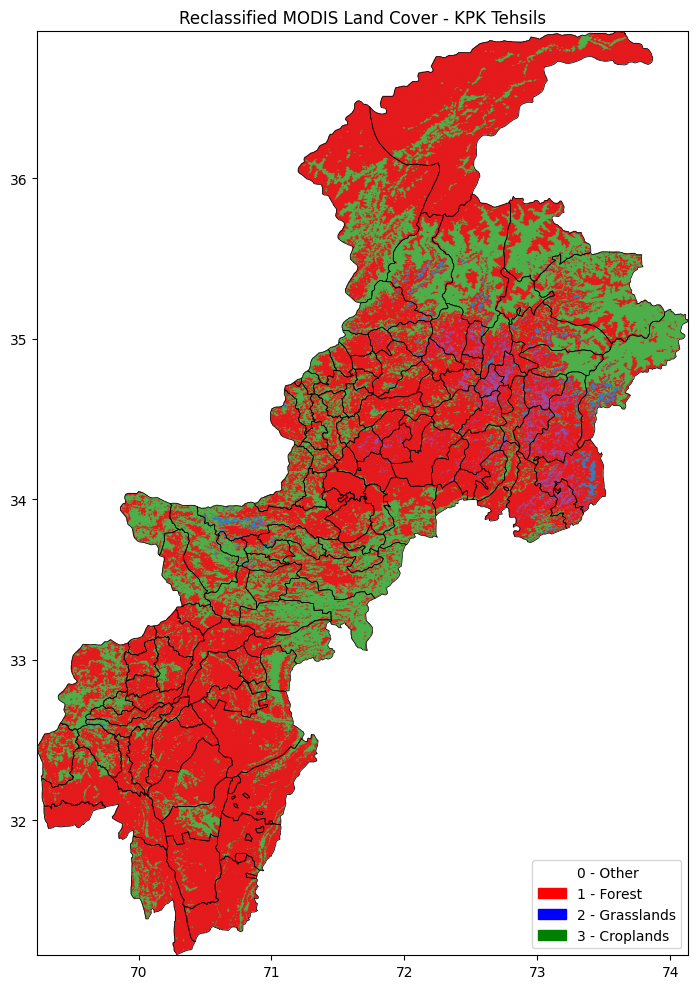

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from rasterio.plot import show

fig, ax = plt.subplots(figsize=(12, 10))

with rasterio.open(reclass_path) as src:
    data_plot = src.read(1).astype(float)
    data_plot[data_plot == 255] = np.nan  # mask nodata

    show(data_plot, transform=src.transform, ax=ax,
         cmap='Set1', vmin=0, vmax=3)

gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)

# Legend
legend_patches = [
    mpatches.Patch(color='white', label='0 - Other'),
    mpatches.Patch(color='red', label='1 - Forest'),
    mpatches.Patch(color='blue', label='2 - Grasslands'),
    mpatches.Patch(color='green', label='3 - Croplands'),
]
ax.legend(handles=legend_patches, loc='lower right')
ax.set_title('Reclassified MODIS Land Cover - KPK Tehsils')
plt.tight_layout()
plt.savefig('reclassified_map.png', dpi=150)
plt.show()